In [ ]:
!pip install agml
!pip install albumentations

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 774.7/774.7 kB 16.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.8/139.8 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 243.2/243.2 kB 16.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 22.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 10.2 MB/s eta 0:00:00
  Attempting uninstall: widgetsnbextension
    Found existing installation: widgetsnbextension 3.6.10
    Uninstalling widgetsnbextension-3.6.10:
      Successfully uninstalled widgetsnbextension-3.6.10
  Attempting uninstall: rich
    Found existing installation: rich 13.9.4
    Uninstalling rich-13.9.4:
      Successfully uninstalled rich-13.9.4
  Attempting uninstall: ipywidgets
    Found existing installation: ipywidgets 7.7.1
    Uninstalling ipywidgets-7.7.1:
      Successfully uninstalled ipywidgets-7.7.1
ERROR: pip's dependency resolver does not currently take into account all the package

In [ ]:
!pip install pytorch-lightning

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.1/823.1 kB 22.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 115.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 90.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 54.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 101.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 961.5/961.5 kB 64.7 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlin

In [ ]:
!pip install ensemble-boxes

In [ ]:
!pip install effdet==0.2.4

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ConvNeXt_Tiny_Weights.IMAGENET1K_V1`. You can also use `weights=ConvNeXt_Tiny_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loss: 2.1194
Accuracy: 0.2005
Confusion Matrix:
[[  6   0  58   0   1   1  18   3  38]
 [ 10   0  37   0   0   2  19   6  48]
 [ 35   1 282   3  34   0 148  34 358]
 [  0   0  11   0   3   0  16   0  75]
 [  6   0  27   1   1   0  12   0  62]
 [  1   0  16   0   3   0  11   7  67]
 [  3   0  30   0  13   0  33   4  13]
 [  3   0  21   0   0   0  13   0  56]
 [  3   0  46   0   0   0  21   2  29]]


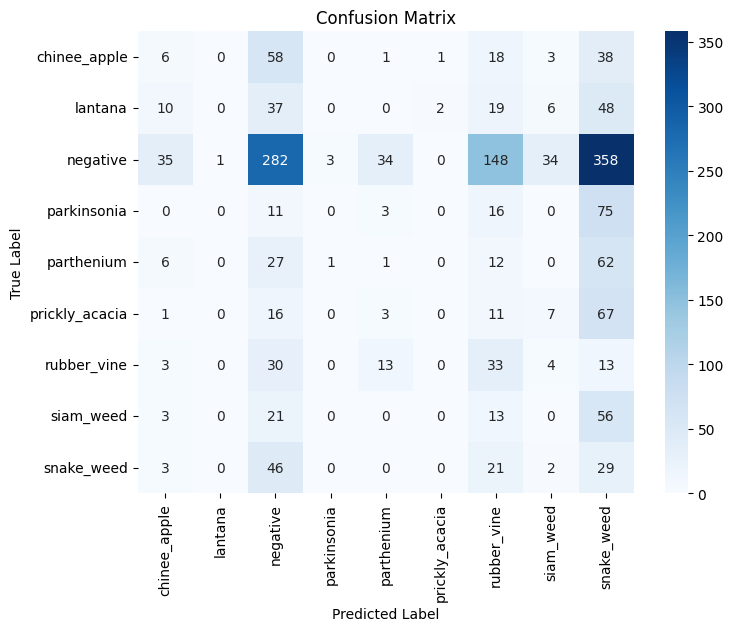

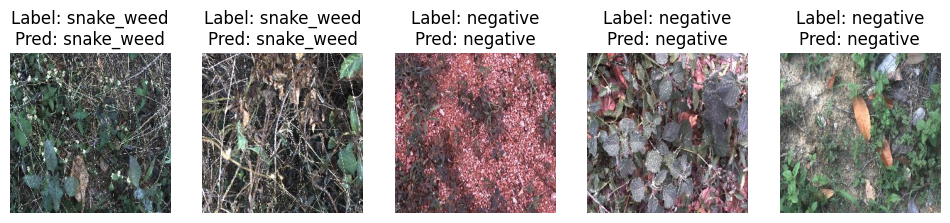

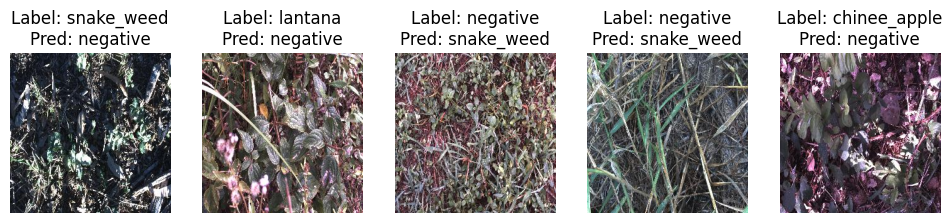

In [ ]:
import agml
import agml.models
import torch
import torchvision
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score

# Load Data
loader = agml.data.AgMLDataLoader('rangeland_weeds_australia')
loader.split(train=0.8, val=0.1, test=0.1)

# Test dataset
loader.test_data.batch(None)
test_ds = loader.test_data.as_torch_dataset()

# Load model
model = torchvision.models.convnext_tiny(pretrained=True)
model.classifier[2] = nn.Linear(model.classifier[2].in_features, loader.num_classes)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
model.eval()

# Lists to store all the inputs, predictions, and labels
all_inputs = []
all_preds = []
all_labels = []
losses = []

correct_images = []
incorrect_images = []
correct_labels = []
incorrect_labels = []
correct_preds = []
incorrect_preds = []

criterion = nn.CrossEntropyLoss()

# Evaluate model
with torch.no_grad():
    for inputs, labels in test_ds:
        inputs = inputs.unsqueeze(0).to(device)
        labels = labels.unsqueeze(0).to(device).long()

        outputs = model(inputs)
        loss = criterion(outputs, labels)

        losses.append(loss.item())

        all_inputs.append(inputs.squeeze(0).cpu())
        preds = outputs.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

        # Collect images based on correctness of classification
        for i in range(len(preds)):
            if preds[i] == labels[i]:
                correct_images.append(inputs[i].cpu())
                correct_labels.append(labels[i].cpu().numpy())
                correct_preds.append(preds[i].cpu().numpy())
            else:
                incorrect_images.append(inputs[i].cpu())
                incorrect_labels.append(labels[i].cpu().numpy())
                incorrect_preds.append(preds[i].cpu().numpy())

# Compute metrics
avg_loss = np.mean(losses)
acc = accuracy_score(all_labels, all_preds)
cm = confusion_matrix(all_labels, all_preds)

# Print metrics
print(f"Loss: {avg_loss:.4f}")
print(f"Accuracy: {acc:.4f}")
print("Confusion Matrix:")
print(cm)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=loader.classes, yticklabels=loader.classes)
plt.title("Confusion Matrix")
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Display correctly classified weed images
if correct_images:
    plt.figure(figsize=(12, 6))
    for i in range(min(5, len(correct_images))):  # Display up to 5 correctly classified images
        plt.subplot(1, 5, i+1)
        img = correct_images[i].permute(1, 2, 0).numpy()  # Convert tensor to numpy
        img = np.clip(img, 0, 255)  # Ensure pixel values are in [0, 255] range
        img = img.astype(np.uint8)  # Convert to uint8 for proper display
        plt.imshow(img)
        plt.title(f"Label: {loader.classes[correct_labels[i]]}\nPred: {loader.classes[correct_preds[i]]}")
        plt.axis('off')
    plt.show()

# Display incorrectly classified weed images
if incorrect_images:
    plt.figure(figsize=(12, 6))
    for i in range(min(5, len(incorrect_images))):  # Display up to 5 incorrectly classified images
        plt.subplot(1, 5, i+1)
        img = incorrect_images[i].permute(1, 2, 0).numpy()  # Convert tensor to numpy
        img = np.clip(img, 0, 255)  # Ensure pixel values are in [0, 255] range
        img = img.astype(np.uint8)  # Convert to uint8 for proper display
        plt.imshow(img)
        plt.title(f"Label: {loader.classes[incorrect_labels[i]]}\nPred: {loader.classes[incorrect_preds[i]]}")
        plt.axis('off')
    plt.show()


# Improvements

Using data augmentation, freezing earlier layers of model while training later layers of model, over-sampling or under-sampling the dataset to balance the classes to a more even distribution can all help improve the perfoormance of the pre-trained model.